<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_039_learning_curves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 39/365 — Learning Curves
## Does giving a model more training data actually help?

Yesterday we used a **validation curve** to understand how a hyperparameter changes model behavior.

Today we keep the model fixed and change only the amount of training data.

A **learning curve** plots model performance against training-set size.

It helps us reason about whether more data may help, whether the model is underfitting, and whether there is a large train-vs-validation gap.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import learning_curve, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge


## 1. Load the real dataset


In [2]:
data = load_diabetes(as_frame=True)
X = data.data.copy()
y = data.target.copy()
print('Dataset shape:', X.shape)
print('Features:', X.columns.tolist())


Dataset shape: (442, 10)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


## 2. Build a fixed model

Today we are **not tuning alpha**. The model stays fixed so only training-set size changes.


In [3]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=10))
])


## 3. Generate the learning curve with 5-fold cross-validation


In [4]:
train_sizes = np.linspace(0.1, 1.0, 8)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

sizes, train_scores, validation_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    train_sizes=train_sizes,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    shuffle=True,
    random_state=42
)

train_rmse = -train_scores.mean(axis=1)
validation_rmse = -validation_scores.mean(axis=1)

results = pd.DataFrame({
    'Training Examples': sizes,
    'Train RMSE': train_rmse,
    'Validation RMSE': validation_rmse
})

display(results.round(3))


,Training Examples,Train RMSE,Validation RMSE
0,35,45.627,59.291
1,80,51.578,57.658
2,126,52.866,55.442
3,171,52.987,55.294
4,216,53.551,55.071
5,262,53.340,54.807
6,307,53.127,54.447
7,353,53.441,54.799


## 4. Visual — Training size vs model error


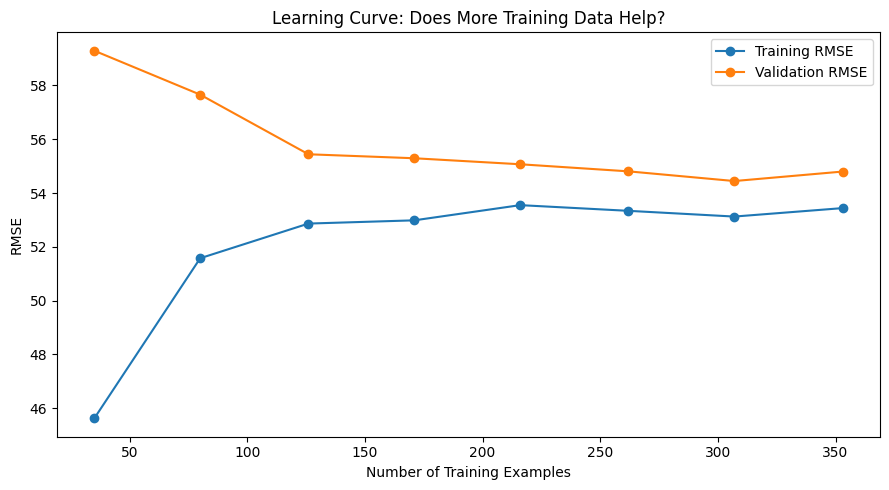

In [5]:
plt.figure(figsize=(9,5))
plt.plot(sizes, train_rmse, marker='o', label='Training RMSE')
plt.plot(sizes, validation_rmse, marker='o', label='Validation RMSE')
plt.xlabel('Number of Training Examples')
plt.ylabel('RMSE')
plt.title('Learning Curve: Does More Training Data Help?')
plt.legend()
plt.tight_layout()
plt.show()


## How to read the graph

**Large train-validation gap** → can indicate high variance / overfitting; more data may help.

**Both errors high and close** → can indicate high bias / underfitting; more data alone may not solve the problem.

**Validation error improves then plateaus** → more data helped initially, but gains are becoming smaller.


## What does this experiment teach?

- More data is **not automatically** the answer to every ML problem.
- Learning curves help diagnose whether more training examples are likely to help.
- A large train-validation gap often points toward variance.
- High and similar training/validation error can point toward bias.
- The shape of the curve matters more than one single score.
- Learning curves are diagnostic tools, not absolute proofs.

> **Before saying “we need more data,” check whether the learning curve actually suggests that more data is likely to help.**


## References

- https://scikit-learn.org/stable/modules/learning_curve.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.learning_curve.html
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
- https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html
